In [1]:
# 用 numpy 实现与门
def AND(x1, x2):
    # 人工设定参数和阈值
    w1, w2 = 0.5, 0.5
    theta = 0.7

    # y = w1*x1 + w2*x2，theta 为阈值
    res = w1 * x1 + w2 * x2
    if res <= theta:
        return 0
    return 1


print("与门输出")


def test_and_gate():
    """与门测试用例：覆盖 4 组真值表输入。"""
    test_cases = [
        # (x1, x2, expected)
        (0, 0, 0),
        (0, 1, 0),
        (1, 0, 0),
        (1, 1, 1),
    ]

    for x1, x2, expected in test_cases:
        pred = AND(x1, x2)
        print(f"输入=({x1}, {x2})，期望={expected}，实际={pred}")
        assert pred == expected, (
            f"测试失败: 输入=({x1}, {x2}), 期望={expected}, 实际={pred}"
        )

    print("所有与门测试通过")


# 运行测试
test_and_gate()


与门输出
输入=(0, 0)，期望=0，实际=0
输入=(0, 1)，期望=0，实际=0
输入=(1, 0)，期望=0，实际=0
输入=(1, 1)，期望=1，实际=1
所有与门测试通过


In [ ]:
import numpy as np 
def NOTAND(x1,x2):
    # 人工设定参数和阈值
    w= np.array([-0.5, -0.5])
    x = np.array([x1,x2])
    b = 0.7
    # np.sum(w*x)中w*x为逐元素乘积，以矩阵的视角为哈达玛积
    res = np.sum(w*x)+b
    if res <= 0:
        return 0
    else:
        return 1

# 与非门真值表测试
for x1, x2, expected in [(0,0,1),(0,1,1),(1,0,1),(1,1,0)]:
    assert NOTAND(x1, x2) == expected, f"失败: ({x1},{x2})"
print("NOTAND 测试通过")

NOTAND 测试通过


In [3]:
import numpy as np

def OR(x1, x2):
    # 或门：任意一个输入为 1 则输出 1
    w = np.array([0.5, 0.5])
    x = np.array([x1, x2])
    b = -0.3  # 偏置：确保 (0,1)/(1,0) 能越过阈值

    res = np.sum(w * x) + b
    if res <= 0:
        return 0
    return 1


# 或门真值表测试
for x1, x2, expected in [(0,0,0),(0,1,1),(1,0,1),(1,1,1)]:
    assert OR(x1, x2) == expected, f"失败: ({x1},{x2})"
print("OR 测试通过")


OR 测试通过


1. 当前所有的三个门均为线性可分的，异或门XOR线性不可分，这也是朴素感知机的问题；不过xor可以用上述的三个门组合来表示非线性。
2. theta或者说偏置（bias）b，其实就是阈值调控。超过阈值就输出，不超过就不输出，类似于电路信号的控制，但是因为每次都要人工选择参数，所以引出了后面一系列通过机器自主学习参数的方式。比如“超过阈值”这一动作就可以视为激活，也就引出了激活函数。
3. xor图见下例 

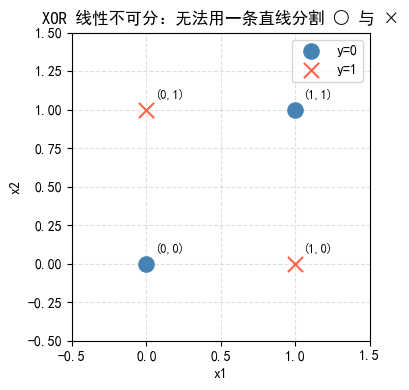

In [5]:
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams['font.family'] = 'SimHei'       # 指定中文字体
plt.rcParams['axes.unicode_minus'] = False   # 负号正常显示

# XOR 真值表：输出 0 用圆圈，输出 1 用叉号
points = [(0, 0, 0), (0, 1, 1), (1, 0, 1), (1, 1, 0)]

fig, ax = plt.subplots(figsize=(4, 4))

for x1, x2, y in points:
    if y == 0:
        ax.scatter(x1, x2, marker='o', s=120, color='steelblue', zorder=3, label='y=0' if (x1,x2)==(0,0) else "")
    else:
        ax.scatter(x1, x2, marker='x', s=120, color='tomato',   zorder=3, label='y=1' if (x1,x2)==(0,1) else "")

# 标注坐标
for x1, x2, y in points:
    ax.annotate(f'({x1},{x2})', xy=(x1, x2), xytext=(x1+0.05, x2+0.07), fontsize=9)

ax.set_xlim(-0.5, 1.5)
ax.set_ylim(-0.5, 1.5)
ax.set_xlabel('x1')
ax.set_ylabel('x2')
ax.set_title('XOR 线性不可分：无法用一条直线分割 ○ 与 ×')
ax.legend()
ax.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()